# Тестовая панель для конфигов

Эта тетрадь нужна только для проверки новой схемы: сценарий и исследование задаются через отдельные `json`-файлы.

In [1]:
from pathlib import Path
import sys
import json

PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / 'synthetic_config_workflow.py').exists():
    PROJECT_DIR = Path('/Users/karimau/Projects_C++/Course Project')
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import synthetic_api as api
import synthetic_config_workflow as cfg

PROJECT_DIR


PosixPath('/Users/karimau/Projects_C++/Course Project')

In [2]:
def show_table(obj, n=5):
    if hasattr(obj, 'head'):
        return obj.head(n)
    return obj[:n]


## 1. Проверяем папки и примерные конфиги

In [3]:
paths = cfg.ensure_study_tree(PROJECT_DIR)
paths


{'root': PosixPath('/Users/karimau/Projects_C++/Course Project'),
 'configs': PosixPath('/Users/karimau/Projects_C++/Course Project/study_configs'),
 'scenarios': PosixPath('/Users/karimau/Projects_C++/Course Project/study_configs/scenarios'),
 'studies': PosixPath('/Users/karimau/Projects_C++/Course Project/study_configs/studies'),
 'outputs': PosixPath('/Users/karimau/Projects_C++/Course Project/study_outputs')}

In [4]:
scenario_json = PROJECT_DIR / 'study_configs' / 'scenarios' / 'base_60x60_rank4.json'
study_json = PROJECT_DIR / 'study_configs' / 'studies' / 'rank_sweep_demo.json'

print('scenario json exists:', scenario_json.exists())
print('study json exists:', study_json.exists())
scenario_json, study_json


scenario json exists: True
study json exists: True


(PosixPath('/Users/karimau/Projects_C++/Course Project/study_configs/scenarios/base_60x60_rank4.json'),
 PosixPath('/Users/karimau/Projects_C++/Course Project/study_configs/studies/rank_sweep_demo.json'))

## 2. Смотрим содержимое файлов

In [5]:
print('=== scenario json ===')
print(scenario_json.read_text(encoding='utf-8')[:1500])

print('=== study json ===')
print(study_json.read_text(encoding='utf-8')[:1500])


=== scenario json ===
{
  "name": "base_60x60_rank4",
  "description": "Базовый синтетический сценарий 60x60, rank=4, случайные пропуски.",
  "tags": [
    "synthetic",
    "base",
    "rank4"
  ],
  "scenario": {
    "matrix": {
      "m": 60,
      "n": 60,
      "rank": 4,
      "factor_distribution": "gaussian",
      "singular_value_profile": "linear",
      "singular_scale": 1.0,
      "coherence_mode": "incoherent",
      "coherence_strength": 0.9,
      "sparse_additive_fraction": 0.0,
      "sparse_additive_scale": 0.0
    },
    "structure": {
      "mode": "none",
      "strength": 0.0,
      "secondary_strength": 0.0
    },
    "missingness_field": {
      "mode": "random",
      "concentration": 1.0,
      "width": 0.15,
      "row_index": null,
      "col_index": null,
      "value_dependence": 0.0
    },
    "mask_sampling": {
      "observed_fraction": 0.35,
      "exact_fraction": true,
      "threshold": null,
      "invert_scores": false
    },
    "split": {
      "

## 3. Загружаем документы

In [6]:
scenario_doc = cfg.load_scenario_document(scenario_json)
study_doc = cfg.load_study_document(study_json)

scenario_doc, study_doc


(ScenarioDocument(name='base_60x60_rank4', description='Базовый синтетический сценарий 60x60, rank=4, случайные пропуски.', tags=['synthetic', 'base', 'rank4'], scenario=ScenarioConfig(matrix=MatrixConfig(m=60, n=60, rank=4, factor_distribution='gaussian', singular_value_profile='linear', singular_scale=1.0, coherence_mode='incoherent', coherence_strength=0.9, sparse_additive_fraction=0.0, sparse_additive_scale=0.0), structure=StructureConfig(mode='none', strength=0.0, secondary_strength=0.0), missingness_field=MissingnessFieldConfig(mode='random', concentration=1.0, width=0.15, row_index=None, col_index=None, value_dependence=0.0), mask_sampling=MaskSamplingConfig(observed_fraction=0.35, exact_fraction=True, threshold=None, invert_scores=False), split=SplitConfig(validation_fraction=0.15, test_fraction=0.15), noise=NoiseConfig(mode='gaussian', std=0.02, outlier_fraction=0.0, outlier_scale=0.0))),
 StudyDocument(name='rank_sweep_demo', description='Перебор истинного ранга при фиксирова

## 4. Предпросмотр сетки исследования

In [7]:
preview_rows = cfg.preview_study_document(study_doc, PROJECT_DIR)
show_table(preview_rows)


[{'study_name': 'rank_sweep_demo',
  'scenario_index': 1,
  'matrix.rank': 4,
  'matrix.m': 60,
  'matrix.n': 60,
  'matrix.factor_distribution': 'gaussian',
  'matrix.singular_value_profile': 'linear',
  'matrix.singular_scale': 1.0,
  'matrix.coherence_mode': 'incoherent',
  'matrix.coherence_strength': 0.9,
  'matrix.sparse_additive_fraction': 0.0,
  'matrix.sparse_additive_scale': 0.0,
  'structure.mode': 'none',
  'structure.strength': 0.0,
  'structure.secondary_strength': 0.0,
  'missingness_field.mode': 'random',
  'missingness_field.concentration': 1.0,
  'missingness_field.width': 0.15,
  'missingness_field.row_index': None,
  'missingness_field.col_index': None,
  'missingness_field.value_dependence': 0.0,
  'mask_sampling.observed_fraction': 0.35,
  'mask_sampling.exact_fraction': True,
  'mask_sampling.threshold': None,
  'mask_sampling.invert_scores': False,
  'split.validation_fraction': 0.15,
  'split.test_fraction': 0.15,
  'noise.mode': 'gaussian',
  'noise.std': 0.02

## 5. Проверяем базовый сценарий отдельно

In [8]:
scenario = api.assemble_scenario(scenario_doc.scenario, seed=42)
print('shape:', scenario.X_structured.shape)
print('rank in config:', scenario.config.matrix.rank)
print('observed fraction:', scenario.mask_split.observed_mask.mean())


shape: (60, 60)
rank in config: 4
observed fraction: 0.35


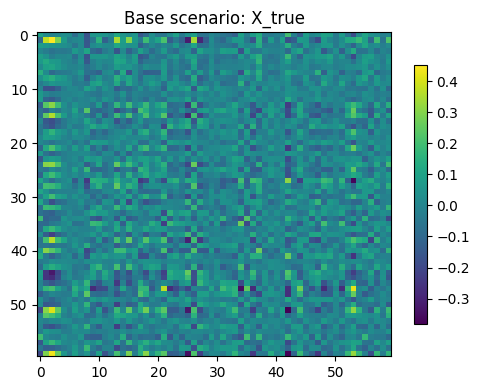

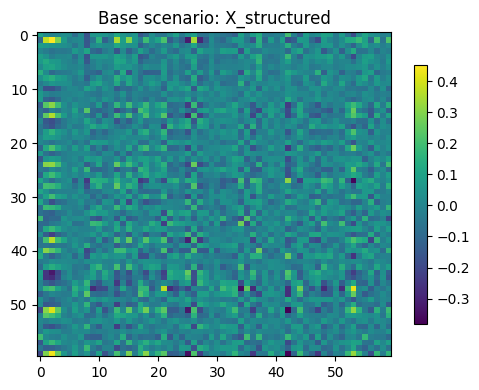

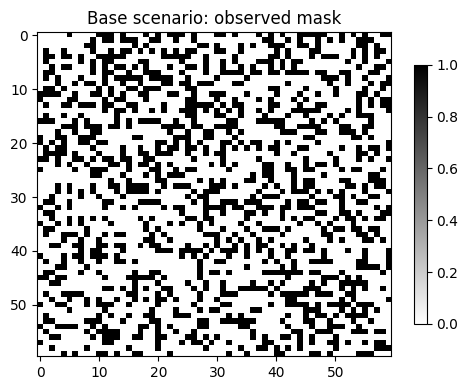

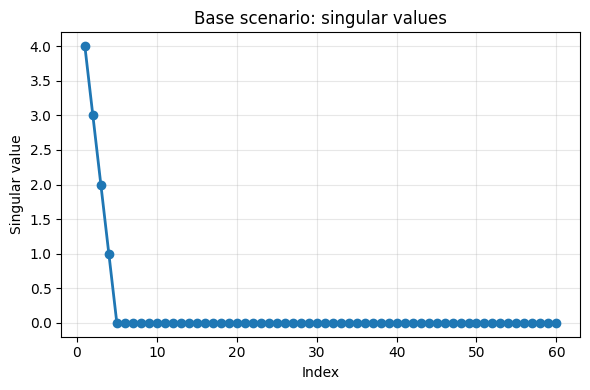

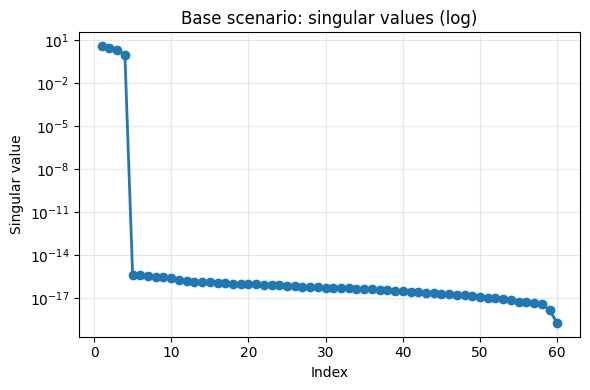

In [9]:
api.plot_matrix(scenario.X_true, title='Base scenario: X_true');
api.plot_matrix(scenario.X_structured, title='Base scenario: X_structured');
api.plot_mask(scenario.mask_split.observed_mask, title='Base scenario: observed mask');
api.plot_singular_values(scenario.X_structured, title='Base scenario: singular values');
api.plot_singular_values(scenario.X_structured, title='Base scenario: singular values (log)', log_scale=True);


## 6. Запуск исследования прямо из файла

In [10]:
study_run = cfg.run_study_from_file(study_json, PROJECT_DIR)
print('records:', len(study_run['records']))
print('summary rows:', len(study_run['summary']))


records: 24
summary rows: 12


In [11]:
show_table(study_run['summary'])


[{'matrix.rank': 4,
  'method': 'rgd',
  'n_runs': 2,
  'avg_test_rmse': 0.032228,
  'std_test_rmse': 0.016815,
  'avg_test_mae': 0.021227,
  'std_test_mae': 0.009861,
  'avg_relative_fro_error': 0.308822,
  'std_relative_fro_error': 0.154118,
  'avg_runtime_sec': 0.051691,
  'std_runtime_sec': 0.00046,
  'avg_iterations': 120.0,
  'std_iterations': 0.0,
  'avg_train_rmse_observed': 0.016502,
  'std_train_rmse_observed': 0.002348},
 {'matrix.rank': 4,
  'method': 'rgd_l2',
  'n_runs': 2,
  'avg_test_rmse': 0.025466,
  'std_test_rmse': 0.0016,
  'avg_test_mae': 0.018352,
  'std_test_mae': 0.000795,
  'avg_relative_fro_error': 0.256521,
  'std_relative_fro_error': 0.003976,
  'avg_runtime_sec': 0.05156,
  'std_runtime_sec': 0.000684,
  'avg_iterations': 120.0,
  'std_iterations': 0.0,
  'avg_train_rmse_observed': 0.01828,
  'std_train_rmse_observed': 0.000289},
 {'matrix.rank': 4,
  'method': 'soft_impute',
  'n_runs': 2,
  'avg_test_rmse': 0.038712,
  'std_test_rmse': 0.000213,
  'avg_t

## 7. Строим график по summary

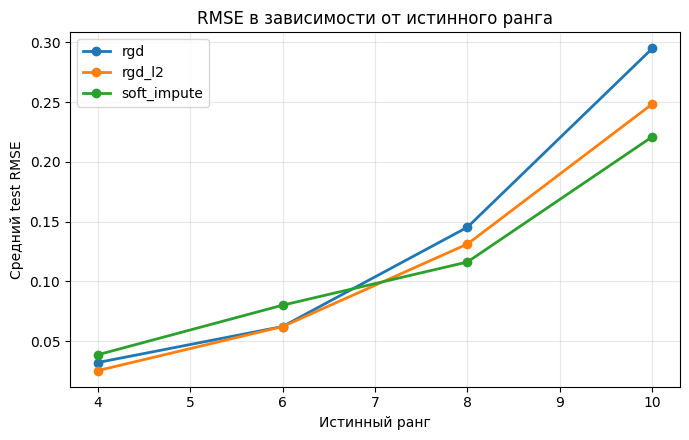

In [12]:
api.plot_metric(
    study_run['summary'],
    x='matrix.rank',
    y='avg_test_rmse',
    hue='method',
    title='RMSE в зависимости от истинного ранга',
    xlabel='Истинный ранг',
    ylabel='Средний test RMSE',
);


## 8. Сохраняем результаты исследования

In [13]:
saved = cfg.save_study_run(study_run, PROJECT_DIR)
saved


{'study_json': PosixPath('/Users/karimau/Projects_C++/Course Project/study_outputs/rank_sweep_demo/rank_sweep_demo_study.json'),
 'manifest_csv': PosixPath('/Users/karimau/Projects_C++/Course Project/study_outputs/rank_sweep_demo/rank_sweep_demo_manifest.csv'),
 'records_csv': PosixPath('/Users/karimau/Projects_C++/Course Project/study_outputs/rank_sweep_demo/rank_sweep_demo_records.csv'),
 'summary_csv': PosixPath('/Users/karimau/Projects_C++/Course Project/study_outputs/rank_sweep_demo/rank_sweep_demo_summary.csv')}

## 9. Дальнейший цикл

1. создаешь новый `scenario json`;
2. создаешь новый `study json`;
3. загружаешь их здесь;
4. смотришь preview;
5. запускаешь исследование;
6. сохраняешь результаты.